# Retrieval-Based Chatbot for Materials

## Setup

In [1]:
%pip install -q sentence-transformers faiss-cpu rank-bm25 nltk pandas numpy matplotlib seaborn gradio transformers torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
from functools import lru_cache
import re
import time
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from rank_bm25 import BM25Okapi
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

c:\Users\olgap\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paths

In [3]:
from pathlib import Path

DATA_DIR = Path("data")  # если ноутбук запускается из папки RAG_for_material_search
print(DATA_DIR.resolve())

C:\Users\olgap\OneDrive\MIPT_Master\04_Generation_NLP\RAG_for_material_search\data


## Data

In [4]:
df_text = pd.read_csv(DATA_DIR / "df_text.csv")
df_numeric = pd.read_csv(DATA_DIR / "df_numeric.csv")

df_text = df_text[[c for c in ["UUID", "text_document", "dataset_type", "eval_labels"] if c in df_text.columns]].copy()
base_cols = ["UUID", "Name (en)", "Kategorie (en)", "Typ", "Bezugsgroesse", "Bezugseinheit", "GWPtotal (A2)"]
df_numeric = df_numeric[[c for c in base_cols if c in df_numeric.columns]].copy()
df = df_text.merge(df_numeric, on="UUID", how="left")
documents = df["text_document"].fillna("").tolist()

queries = pd.read_csv(DATA_DIR / "eval_queries.csv")
qrels = pd.read_csv(DATA_DIR / "eval_qrels.csv")
qrels = qrels[qrels["relevance"] > 0][["query_id", "UUID", "relevance"]].drop_duplicates()

demo_queries = queries["query_text"].tolist()[:3]
print("materials:", len(df), "queries:", len(queries), "qrels:", len(qrels))
print("demo_queries:", demo_queries)

materials: 2491 queries: 3 qrels: 144
demo_queries: ['ready mixed concrete', 'glass wool insulation', 'roofing membrane']


## Embeddings and FAISS

In [5]:
MODEL_NAME = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
model = SentenceTransformer(MODEL_NAME)

t0 = time.time()
embeddings = model.encode(documents, normalize_embeddings=True, show_progress_bar=True)
embeddings = np.array(embeddings, dtype="float32")
print("embeddings:", embeddings.shape, "time_sec:", round(time.time() - t0, 2))

d = embeddings.shape[1]

index_flat = faiss.IndexFlatIP(d)
index_flat.add(embeddings)

nlist = min(100, max(16, len(embeddings) // 25))
quantizer = faiss.IndexFlatIP(d)
index_ivf = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)
index_ivf.train(embeddings)
index_ivf.add(embeddings)
index_ivf.nprobe = min(16, nlist)

index_hnsw = faiss.IndexHNSWFlat(d, 32, faiss.METRIC_INNER_PRODUCT)
index_hnsw.hnsw.efSearch = 64
index_hnsw.add(embeddings)

FAISS_INDICES = {
    "FAISS Flat": index_flat,
    "FAISS IVF": index_ivf,
    "FAISS HNSW": index_hnsw
}
print({k: v.ntotal for k, v in FAISS_INDICES.items()})

Batches: 100%|██████████| 78/78 [00:06<00:00, 11.42it/s]


embeddings: (2491, 384) time_sec: 6.93
{'FAISS Flat': 2491, 'FAISS IVF': 2491, 'FAISS HNSW': 2491}


## BM25

In [6]:
try:
    _ = stopwords.words("english")
except LookupError:
    nltk.download("stopwords", quiet=True)

STOPWORDS = set(stopwords.words("english"))
STEMMER = SnowballStemmer("english")

def normalize_text(text):
    tokens = re.findall(r"[a-z0-9]+", str(text).lower())
    tokens = [t for t in tokens if t not in STOPWORDS]
    return [STEMMER.stem(t) for t in tokens]

tokenized_docs = [normalize_text(x) for x in documents]
bm25 = BM25Okapi(tokenized_docs)
print("bm25_docs:", len(tokenized_docs))

bm25_docs: 2491


## Retrieval Functions

In [7]:
TYPE_BONUS = {
    "typical": {
        "representative dataset": 0.05,
        "average dataset": 0.03,
        "generic dataset": 0.01,
        "specific dataset": 0.00
    },
    "product": {
        "specific dataset": 0.05,
        "representative dataset": 0.03,
        "average dataset": 0.01,
        "generic dataset": 0.00
    }
}

def pack_result(idx, score, score_key):
    r = df.iloc[idx]
    dataset_type = r.get("dataset_type", r.get("Typ", ""))
    return {
        "uuid": r["UUID"],
        "text": r["text_document"],
        "name": r.get("Name (en)", ""),
        "category": r.get("Kategorie (en)", ""),
        "dataset_type": dataset_type,
        "unit": f"{r.get('Bezugsgroesse', '')} {r.get('Bezugseinheit', '')}",
        "gwp": r.get("GWPtotal (A2)", np.nan),
        score_key: float(score)
    }

@lru_cache(maxsize=256)
def encode_query(query):
    return np.array(model.encode([query], normalize_embeddings=True), dtype="float32")

def vector_search(query, index_obj, top_k=10, top_candidates=100):
    qv = encode_query(query)
    scores, indices = index_obj.search(qv, top_candidates)
    out = [pack_result(i, s, "similarity") for s, i in zip(scores[0], indices[0])]
    return out[:top_k]

def keyword_search(query, top_k=10):
    q_tokens = normalize_text(query)
    scores = bm25.get_scores(q_tokens)
    top_idx = np.argsort(scores)[::-1][:top_k]
    out = []
    for i in top_idx:
        if scores[i] <= 0:
            continue
        out.append(pack_result(i, scores[i], "bm25_score"))
    return out

def hybrid_search_rrf(query, top_k=10, top_candidates=100, rrf_k=60):
    dense = vector_search(query, FAISS_INDICES["FAISS Flat"], top_k=top_candidates, top_candidates=top_candidates)
    sparse = keyword_search(query, top_k=top_candidates)
    fused = {}
    for rank, r in enumerate(dense, 1):
        u = r["uuid"]
        if u not in fused:
            fused[u] = dict(r)
            fused[u]["rrf_score"] = 0.0
        fused[u]["rrf_score"] += 1.0 / (rrf_k + rank)
    for rank, r in enumerate(sparse, 1):
        u = r["uuid"]
        if u not in fused:
            fused[u] = dict(r)
            fused[u]["rrf_score"] = 0.0
        fused[u]["rrf_score"] += 1.0 / (rrf_k + rank)
    out = list(fused.values())
    out.sort(key=lambda x: x["rrf_score"], reverse=True)
    return out[:top_k]

def semantic_gate_uuids(
    query,
    tau_abs=0.50,
    delta=0.08,
    probe_k=120,
    n_min=20,
    n_max=70
):
    probe = vector_search(
        query,
        FAISS_INDICES["FAISS Flat"],
        top_k=probe_k,
        top_candidates=probe_k
    )

    if not probe:
        return set()

    sim_top1 = float(probe[0].get("similarity", 0.0))
    tau = max(float(tau_abs), sim_top1 - float(delta))
    passed = [r for r in probe if float(r.get("similarity", -1.0)) >= tau]

    if len(passed) < int(n_min):
        passed = probe[:min(int(n_min), len(probe))]

    if len(passed) > int(n_max):
        passed = passed[:int(n_max)]

    return {r["uuid"] for r in passed}

def recommend_materials(
    query,
    method="hybrid",
    mode="typical",
    top_k=10,
    top_candidates=100,
    use_type_bonus=True,
    use_gwp_rerank=True,
    use_semantic_gate=True,
    tau_abs=0.50,
    delta=0.08,
    probe_k=120,
    gate_n_min=20,
    gate_n_max=70
):
    if method == "bm25":
        base = keyword_search(query, top_k=top_candidates)
        score_key = "bm25_score"
    elif method == "vector":
        base = vector_search(query, FAISS_INDICES["FAISS Flat"], top_k=top_candidates, top_candidates=top_candidates)
        score_key = "similarity"
    else:
        base = hybrid_search_rrf(query, top_k=top_candidates, top_candidates=top_candidates)
        score_key = "rrf_score"

    base_before_gate = list(base)
    if use_semantic_gate:
        allowed_uuids = semantic_gate_uuids(
            query,
            tau_abs=tau_abs,
            delta=delta,
            probe_k=probe_k,
            n_min=gate_n_min,
            n_max=gate_n_max
        )
        if allowed_uuids:
            base = [r for r in base if r["uuid"] in allowed_uuids]

    if len(base) < top_k:
        base = base_before_gate

    bonus_map = TYPE_BONUS.get(mode, TYPE_BONUS["typical"])
    for r in base:
        r["type_bonus"] = bonus_map.get(str(r.get("dataset_type", "")).strip(), 0.0) if use_type_bonus else 0.0
        r["score_with_type"] = float(r.get(score_key, 0.0)) + r["type_bonus"]

    base.sort(key=lambda x: x["score_with_type"], reverse=True)
    ranked = base[:top_candidates]

    if use_gwp_rerank:
        ranked.sort(
            key=lambda x: (
                pd.isna(x.get("gwp")),
                x.get("gwp") if pd.notna(x.get("gwp")) else np.inf,
                -x.get("score_with_type", 0.0)
            )
        )

    return ranked[:top_k]

### Semantic Gate Before GWP Re-ranking

This notebook uses a two-stage ranking safeguard to keep results relevant while still optimizing for low GWP:

1. **Semantic gate (dynamic threshold on cosine similarity)**
   - We first build a probe set with dense retrieval (`vector_search`) using `probe_k`.
   - We compute a dynamic threshold:
     - `tau = max(tau_abs, top1_similarity - delta)`
   - Only candidates above `tau` are kept.
   - The pool size is stabilized with bounds:
     - minimum `gate_n_min`
     - maximum `gate_n_max`

2. **Type bonus and optional GWP rerank**
   - After semantic filtering, the existing scoring logic is applied (`score_with_type`).
   - If enabled, candidates are re-ranked by GWP **inside the semantically valid pool**.

Why this helps:
- Prevents very low-relevance items from entering the GWP optimization stage.
- Keeps candidate count adaptive per query (instead of fixed `top_candidates`).
- Preserves robustness with fallback: if the gate returns too few items (`< top_k`), the pipeline uses the original candidate list.

Future notes:
- The semantic threshold can be calibrated using labeled data (`eval_queries.csv` + `eval_qrels.csv`) to pick robust values for `tau_abs`, `delta`, and gate size bounds.
- GWP is currently used as a reranking signal only, but in future it can also be indexed/normalized as an additional retrieval feature if multi-objective retrieval is needed.

## Metrics

In [8]:
def query_to_id(query_text):
    m = queries.loc[queries["query_text"] == query_text, "query_id"]
    if len(m) == 0:
        raise ValueError(f"query not found: {query_text}")
    return m.iloc[0]

def results_to_run_df(results, query_text):
    qid = query_to_id(query_text)
    return pd.DataFrame([
        {"query_id": qid, "UUID": r["uuid"], "rank": rank}
        for rank, r in enumerate(results, 1)
    ])

def recall_at_k(run_df, qrels_df, k):
    run_k = run_df[run_df["rank"] <= k]
    rel = qrels_df[qrels_df["relevance"] > 0][["query_id", "UUID"]].drop_duplicates()
    hit = run_k.merge(rel, on=["query_id", "UUID"], how="inner")
    hit_count = hit.groupby("query_id")["UUID"].nunique()
    rel_count = rel.groupby("query_id")["UUID"].nunique()
    return (hit_count / rel_count).reindex(rel_count.index, fill_value=0).mean()

def evaluate_method(method_name, search_fn, top_k=20):
    t0 = time.time()
    runs = []
    for q in demo_queries:
        res = search_fn(q, top_k=top_k)
        runs.append(results_to_run_df(res, q))
    run_df = pd.concat(runs, ignore_index=True)
    return {
        "method": method_name,
        "latency_ms": (time.time() - t0) * 1000,
        "Recall@1": recall_at_k(run_df, qrels, 1),
        "Recall@5": recall_at_k(run_df, qrels, 5),
        "Recall@10": recall_at_k(run_df, qrels, 10),
        "Recall@20": recall_at_k(run_df, qrels, 20)
    }

## Benchmark and Plot

,method,latency_ms,Recall@1,Recall@5,Recall@10,Recall@20
0,BM25 (keywords),38.226128,0.025327,0.126637,0.253273,0.473214
2,Hybrid RRF (base),34.562349,0.025327,0.126637,0.242162,0.379274
1,FAISS Flat (semantic),212.466002,0.025327,0.104415,0.188627,0.310513
3,Hybrid + Type bonus,44.553041,0.021324,0.085073,0.180397,0.306397
4,Hybrid + Type + GWP,48.063278,0.021324,0.048822,0.115750,0.306397


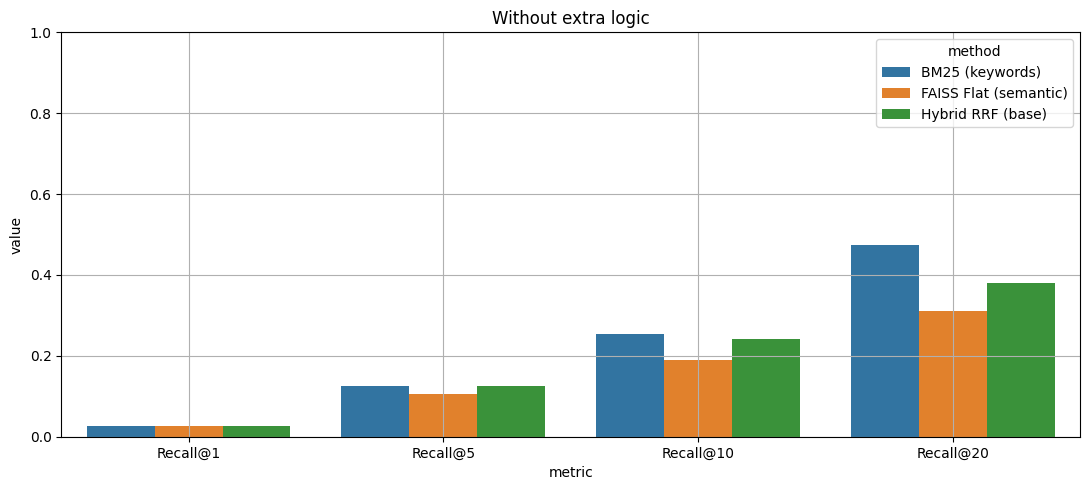

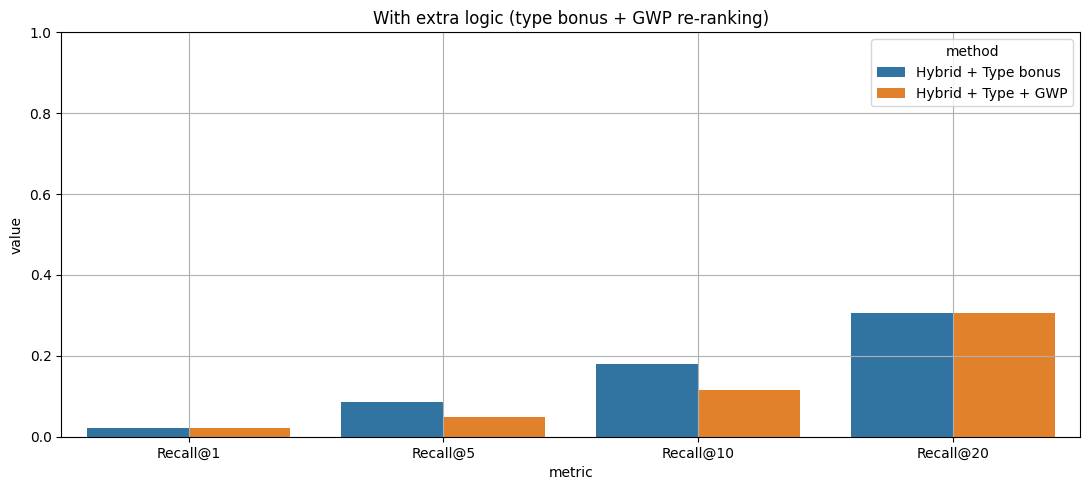

In [9]:
rows = []

rows.append(evaluate_method("BM25 (keywords)", lambda q, top_k=20: keyword_search(q, top_k=top_k), top_k=20))
rows.append(evaluate_method("FAISS Flat (semantic)", lambda q, top_k=20: vector_search(q, FAISS_INDICES["FAISS Flat"], top_k=top_k, top_candidates=50), top_k=20))
rows.append(evaluate_method("Hybrid RRF (base)", lambda q, top_k=20: hybrid_search_rrf(q, top_k=top_k, top_candidates=50), top_k=20))

rows.append(
    evaluate_method(
        "Hybrid + Type bonus",
        lambda q, top_k=20: recommend_materials(
            q, method="hybrid", mode="typical", top_k=top_k, top_candidates=50,
            use_type_bonus=True, use_gwp_rerank=False
        ),
        top_k=20,
    )
)

rows.append(
    evaluate_method(
        "Hybrid + Type + GWP",
        lambda q, top_k=20: recommend_materials(
            q, method="hybrid", mode="typical", top_k=top_k, top_candidates=50,
            use_type_bonus=True, use_gwp_rerank=True
        ),
        top_k=20,
    )
)

metrics_df = pd.DataFrame(rows)
display(metrics_df.sort_values("Recall@20", ascending=False))

base_methods = ["BM25 (keywords)", "FAISS Flat (semantic)", "Hybrid RRF (base)"]
enhanced_methods = ["Hybrid + Type bonus", "Hybrid + Type + GWP"]

base_df = metrics_df[metrics_df["method"].isin(base_methods)].copy()
enhanced_df = metrics_df[metrics_df["method"].isin(enhanced_methods)].copy()

plot_base = base_df.melt(
    id_vars=["method"],
    value_vars=["Recall@1", "Recall@5", "Recall@10", "Recall@20"],
    var_name="metric",
    value_name="value"
)
plot_enhanced = enhanced_df.melt(
    id_vars=["method"],
    value_vars=["Recall@1", "Recall@5", "Recall@10", "Recall@20"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_base, x="metric", y="value", hue="method")
plt.ylim(0, 1)
plt.title("Without extra logic")
plt.tight_layout()
plt.grid(True)
plt.show()

plt.figure(figsize=(11, 5))
sns.barplot(data=plot_enhanced, x="metric", y="value", hue="method")
plt.ylim(0, 1)
plt.title("With extra logic (type bonus + GWP re-ranking)")
plt.tight_layout()
plt.grid(True)
plt.show()

## Demo

In [10]:
def print_top(results, title, n=3):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)
    for i, r in enumerate(results[:n], 1):
        score = r.get("score_with_type", r.get("rrf_score", r.get("similarity", r.get("bm25_score", np.nan))))
        print(f"{i}. {r.get('name', '')}")
        print(f"   UUID: {r['uuid']}")
        print(f"   Category: {r.get('category', '')}")
        print(f"   Dataset type: {r.get('dataset_type', '')}")
        print(f"   GWP: {r.get('gwp', np.nan)}")
        print(f"   Score: {score:.4f}")

for q in demo_queries:
    print_top(
        recommend_materials(
            q, method="vector", mode="typical", top_k=10, top_candidates=50,
            use_type_bonus=True, use_gwp_rerank=True
        ),
        f"FAISS Flat + Type + GWP | {q}"
    )
    print_top(
        recommend_materials(
            q, method="bm25", mode="typical", top_k=10, top_candidates=50,
            use_type_bonus=True, use_gwp_rerank=True
        ),
        f"BM25 + Type + GWP | {q}"
    )
    print_top(
        recommend_materials(
            q, method="hybrid", mode="typical", top_k=10, top_candidates=50,
            use_type_bonus=True, use_gwp_rerank=True
        ),
        f"Hybrid RRF + Type + GWP | {q}"
    )


FAISS Flat + Type + GWP | ready mixed concrete
1. Paving stone of 100% FCN-Klimabeton®
   UUID: 7accbfbe-0b18-4329-bf24-9d7a699c0cb4
   Category: 'Mineral building products' / 'Mortar and Concrete' / 'Ready mixed concrete'
   Dataset type: specific dataset
   GWP: 6.85036
   Score: 0.6284
2. Paving stone of 85% FCN-Klimabeton®
   UUID: 77273865-cad6-4ecf-86b7-c41ebe39456c
   Category: 'Mineral building products' / 'Mortar and Concrete' / 'Ready mixed concrete'
   Dataset type: specific dataset
   GWP: 9.37013
   Score: 0.6328
3. Concrete paving stone 6 cm multicoloured
   UUID: 2bfef475-b573-4c6c-8f0c-b22bdb65c398
   Category: 'Mineral building products' / 'Bricks, blocks and elements' / 'Precast concrete elements and goods'
   Dataset type: average dataset
   GWP: 14.4849266496791
   Score: 0.6655

BM25 + Type + GWP | ready mixed concrete
1. Building products made of concrete and concrete elements - Firmengruppe Max Bögl - Concrete C30/37 blast furnace cement
   UUID: 69cb90b8-560a-4

## Chatbot Function

In [11]:
def chatbot_answer(query, method="hybrid", mode="typical", top_k=5):
    return recommend_materials(
        query,
        method=method,
        mode=mode,
        top_k=top_k,
        top_candidates=50,
        use_type_bonus=True,
        use_gwp_rerank=True,
    )

chatbot_answer("ready mixed concrete", method="hybrid", mode="typical", top_k=5)

[{'uuid': '7accbfbe-0b18-4329-bf24-9d7a699c0cb4',
  'text': "Product: Paving stone of 100% FCN-Klimabeton®. Category: 'Mineral building products' / 'Mortar and Concrete' / 'Ready mixed concrete'. Declared unit: 1 qm. Standard: 'DIN EN 15804+A2' / 'ISO 14025'. Country: DE. Declaration owner: F. C. Nüdling Betonelemente GmbH + Co. KG. Environmental indicators (A1-A3): Global Warming Potential — Total (GWPtotal (A2)): 6.85036 kg CO2-eq; Global Warming Potential — Fossil (GWPfossil (A2)): 7.514 kg CO2-eq; Acidification Potential (AP (A2)): 0.02165 mol H+-eq; Ozone Depletion Potential (ODP (A2)): 3.8917e-11 kg CFC-11-eq; Eutrophication Potential — Freshwater (EPfreshwater (A2)): 1.6379e-05 kg P-eq; Primary Energy Non-Renewable — Total (PENRT): 95.5 MJ; Primary Energy Renewable — Total (PERT): 35.665 MJ.",
  'name': 'Paving stone of 100% FCN-Klimabeton®',
  'category': "'Mineral building products' / 'Mortar and Concrete' / 'Ready mixed concrete'",
  'dataset_type': 'specific dataset',
  'uni

## Gradio Chatbot

In [ ]:
import os
from pathlib import Path

import gradio as gr
import requests


def _load_env(path=".env"):
    env_path = Path(path)
    if not env_path.exists():
        return
    for raw_line in env_path.read_text(encoding="utf-8").splitlines():
        line = raw_line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, value = line.split("=", 1)
        key = key.strip()
        value = value.strip().strip('"').strip("'")
        if key:
            # Keep .env as the source of truth for notebook runs.
            os.environ[key] = value


def _llm_settings():
    # Try common notebook working directories.
    for env_candidate in (Path(".env"), Path("RAG_for_material_search/.env")):
        _load_env(env_candidate)

    api_key = os.getenv("FEATHERLESS_API_KEY", "").strip()
    base_url = os.getenv("FEATHERLESS_BASE_URL", "https://api.featherless.ai").rstrip("/")
    model_name = os.getenv("FEATHERLESS_MODEL", "qywu/Qwen3-32B-Instruct")
    return api_key, base_url, model_name


def format_top5(results):
    lines = []
    for i, r in enumerate(results[:5], 1):
        score = r.get("score_with_type", r.get("rrf_score", r.get("similarity", r.get("bm25_score", np.nan))))
        lines.append(
            f"{i}. {r.get('name', '')}\n"
            f"   UUID: {r['uuid']}\n"
            f"   Category: {r.get('category', '')}\n"
            f"   Dataset type: {r.get('dataset_type', '')}\n"
            f"   Unit: {r.get('unit', '')}\n"
            f"   GWP: {r.get('gwp', np.nan)}\n"
            f"   Score: {score:.4f}"
        )
    return "\n\n".join(lines)


def _build_context(results):
    rows = []
    for i, r in enumerate(results[:5], 1):
        rows.append(
            f"{i}) name={r.get('name', '')}; category={r.get('category', '')}; "
            f"dataset_type={r.get('dataset_type', '')}; unit={r.get('unit', '')}; "
            f"gwp={r.get('gwp', np.nan)}; uuid={r.get('uuid', '')}"
        )
    return "\n".join(rows)


def llm_interpretation(query, results):
    api_key, base_url, model_name = _llm_settings()
    if not api_key:
        return (
            "FEATHERLESS_API_KEY is empty. Add your key to .env and rerun this cell."
        )

    context = _build_context(results)
    system_msg = (
        "You are a sustainable construction materials assistant. "
        "Use only provided context. If data is missing, explicitly say so."
    )
    user_msg = (
        "Task:\n"
        "1) Summarize why the retrieved materials are relevant to the request.\n"
        "2) Compare GWP briefly and highlight trade-offs.\n"
        "3) Provide possible building elements that can be built using these material types.\n"
        "4) Keep it concise: 3-5 bullet points.\n\n"
        f"User query: {query}\n\n"
        f"Top materials context:\n{context}"
    )

    payload = {
        "model": model_name,
        "messages": [
            {"role": "system", "content": system_msg},
            {"role": "user", "content": user_msg},
        ],
        "temperature": 0.2,
        "max_tokens": 450,
    }
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json",
    }

    if base_url.endswith("/v1"):
        endpoint = f"{base_url}/chat/completions"
    else:
        endpoint = f"{base_url}/v1/chat/completions"

    try:
        response = requests.post(
            endpoint,
            headers=headers,
            json=payload,
            timeout=60,
        )
        if response.status_code >= 400:
            return f"LLM API error {response.status_code}: {response.text[:500]}"

        data = response.json()
        return data["choices"][0]["message"]["content"].strip()
    except Exception as e:
        return f"LLM error: {e}"


def chat_fn(message, history):
    try:
        results = recommend_materials(
            message,
            method="hybrid",
            mode="typical",
            top_k=5,
            top_candidates=50,
            use_type_bonus=True,
            use_gwp_rerank=True,
            use_semantic_gate=True,
        )
        llm_answer = llm_interpretation(message, results)
        return f"{llm_answer}\n\nTop-5 materials:\n\n{format_top5(results)}"
    except Exception as e:
        return f"Error: {e}"


with gr.Blocks() as demo:
    gr.Markdown("## Materials Retrieval Chatbot")
    gr.Markdown("Hybrid RRF + semantic gate + GWP reranking + Featherless Qwen interpretation")

    gr.ChatInterface(
        fn=chat_fn,
        title="Materials Bot",
        examples=[
            "ready mixed concrete for external pavement",
            "glass wool insulation for lightweight walls",
            "roofing membrane for flat roof waterproofing",
        ],
    )


demo.launch()

* Running on local URL:  http://127.0.0.1:7862
* To create a public link, set `share=True` in `launch()`.
